In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import subprocess
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


CompletedProcess(args=['python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

In [3]:
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

nlp = spacy.load("en_core_web_sm")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
resume_text = """
Experienced Python developer with skills in FastAPI, MongoDB, and REST APIs.
Built web scraping pipelines using BeautifulSoup and Playwright.
Familiar with spaCy and scikit-learn for NLP tasks.
Used Git and Docker for version control and containerization.
"""

jd_text = """
Looking for a backend engineer with strong Python skills.
Must know Django or FastAPI, PostgreSQL, Redis, and Docker.
Experience with AWS, Kubernetes, and CI/CD pipelines preferred.
NLP or machine learning experience is a plus.
"""

print("Resume length:", len(resume_text.split()), "words")
print("JD length:", len(jd_text.split()), "words")

Resume length: 36 words
JD length: 34 words


In [5]:
def preprocess(text):
    """
    Cleans and normalizes text for NLP:
    - Lowercases all words
    - Removes stopwords (the, and, is...)
    - Removes punctuation
    - Lemmatizes: running->run, libraries->library
    """
    doc = nlp(text.lower())
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop       # remove common words
        and not token.is_punct     # remove . , ! etc
        and token.is_alpha         # keep only real words
    ]
    return " ".join(tokens)

# See it in action
sample = "She is managing multiple engineering projects and libraries."
print("Original :", sample)
print("Processed:", preprocess(sample))

Original : She is managing multiple engineering projects and libraries.
Processed: manage multiple engineering project library


In [6]:
SKILLS = {
    "python", "java", "javascript", "react", "node", "sql", "mongodb",
    "fastapi", "django", "flask", "docker", "kubernetes", "aws", "git",
    "machine learning", "deep learning", "nlp", "spacy", "scikit-learn",
    "pandas", "numpy", "tensorflow", "pytorch", "rest api", "graphql",
    "postgresql", "redis", "linux", "agile", "scrum", "beautifulsoup",
    "playwright", "nlp", "regression", "classification"
}

def extract_skills(text):
    text_lower = text.lower()
    return {skill for skill in SKILLS if skill in text_lower}

resume_skills = extract_skills(resume_text)
jd_skills     = extract_skills(jd_text)

print("Skills in resume:", sorted(resume_skills))
print("Skills in JD    :", sorted(jd_skills))

Skills in resume: ['beautifulsoup', 'docker', 'fastapi', 'git', 'mongodb', 'nlp', 'playwright', 'python', 'rest api', 'scikit-learn', 'spacy']
Skills in JD    : ['aws', 'django', 'docker', 'fastapi', 'kubernetes', 'machine learning', 'nlp', 'postgresql', 'python', 'redis', 'sql']


In [7]:
matched = resume_skills & jd_skills   # set intersection
missing = jd_skills - resume_skills   # in JD but not resume
extra   = resume_skills - jd_skills   # in resume but not JD

print(f"Matched  : {sorted(matched)}")
print(f"Missing  : {sorted(missing)}")
print(f"Extra    : {sorted(extra)}")

Matched  : ['docker', 'fastapi', 'nlp', 'python']
Missing  : ['aws', 'django', 'kubernetes', 'machine learning', 'postgresql', 'redis', 'sql']
Extra    : ['beautifulsoup', 'git', 'mongodb', 'playwright', 'rest api', 'scikit-learn', 'spacy']


In [8]:
processed_resume = preprocess(resume_text)
processed_jd     = preprocess(jd_text)

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform([processed_resume, processed_jd])

score = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])[0][0]
print(f"Overall match score: {round(score * 100, 1)}%")

Overall match score: 19.0%


In [9]:
results_df = pd.DataFrame({
    "Category": ["Matched skills", "Missing skills", "Extra on resume", "Match score"],
    "Details": [
        ", ".join(sorted(matched)),
        ", ".join(sorted(missing)),
        ", ".join(sorted(extra)),
        f"{round(score * 100, 1)}%"
    ]
})

results_df

,Category,Details
0,Matched skills,"docker, fastapi, nlp, python"
1,Missing skills,"aws, django, kubernetes, machine learning, pos..."
2,Extra on resume,"beautifulsoup, git, mongodb, playwright, rest ..."
3,Match score,19.0%


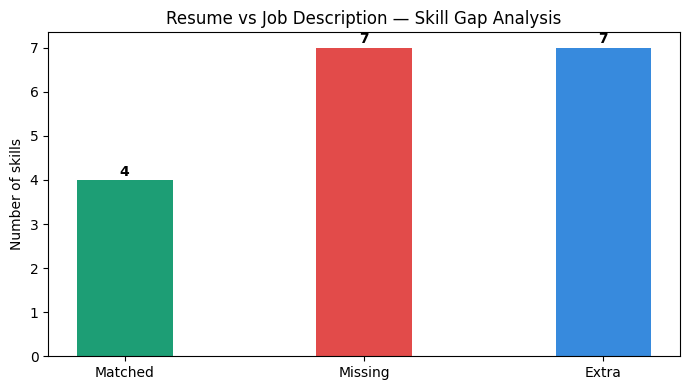

In [10]:
import matplotlib.pyplot as plt

categories = ["Matched", "Missing", "Extra"]
counts = [len(matched), len(missing), len(extra)]
colors = ["#1D9E75", "#E24B4A", "#378ADD"]

plt.figure(figsize=(7, 4))
bars = plt.bar(categories, counts, color=colors, width=0.4)
plt.title("Resume vs Job Description — Skill Gap Analysis")
plt.ylabel("Number of skills")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("skill_gap.png")
plt.show()